# Demo: R Functions
Up to now, we have used a variety of different functions designed by other developers. Sometimes we need to execute an operation multiple times, and most often it is reasonable to write a function to do so. Whenever you have copied and pasted a block of code more than twice, you should consider writing a function (Wickham et al. 2023).

The first step in writing a function, is picking a name and assigning `<- function(){}` to it.

In [1]:
testfun <- function() {}

To run the function, we have to call the assigned name with the brackets. The function `testfun` gives no output, which is why we get `NULL` back.

In [2]:
testfun()

NULL

In [3]:
class(testfun)

[1] "function"

To make the function actually do something, we need to specify what should be done within the curly brackets `{}`. The following function always prints the same statement and accepts no input values:

In [5]:
testfun <- function() {
    print("this function does nothing")
}

testfun()

[1] "this function does nothing"


If we want the function to accept some input values, we have to define them within the round brackets. For example, I specify a variable named `sometext` and can call this variable within the execution.

In [6]:
testfun <- function(sometext) {
    print(sometext)
}

testfun(sometext = "this function does slightly more, but still not much")

[1] "this function does slightly more, but still not much"


Let’s take a more practical example. Say we want a function that calculates our age if provided with the date of our birthday. We can use `Sys.time()` to provide today’s date and `difftime()` to calculate the time difference between today and our birthday.

In [33]:
my_age <- function(birthday, output_unit) {
    today <- difftime(Sys.time(),
            birthday, units = output_unit)
}

my_age(birthday = "1997-04-23", output_unit = "days")

As we already know from using other functions, if we declare our variables in the order that we initially listed them, we do not need to specify the parameters (no need of `birthday =` and `output_unit =`).

In [8]:
my_age("1997-04-23", "days")

Time difference of 10612.44 days

If we want any of our parameters to have default value, we can assign an initial value to the parameter when declaring the variables within the round brackets.

In [30]:
my_age <- function(birthday, output_unit = "days") {
    difftime(Sys.time(), birthday, units = output_unit)
}

# if not stated otherwise, our function uses the unit "days"
my_age("1997-04-23")

Time difference of 10612.45 days

In [10]:
# We can still overwrite units
my_age("1997-04-23", "hours")

Time difference of 254698.5 hours

All you need to do now is run execute the function deceleration `(myage <- function... etc.)` at the beginning of your script, and you can use the function for your entire R session.

**Important**: Always try to make your function self sufficient: Only use objects within your function that are either passed as function arguments or created within the funtion. See more on this topic [here](https://raps-with-r.dev/fprog.html#referentially-transparent-and-pure-functions), in the online version of the book by Rodrigues (2023).

# Tasks and inputs

## Task 1: Write your own functions
Create the following two functions:

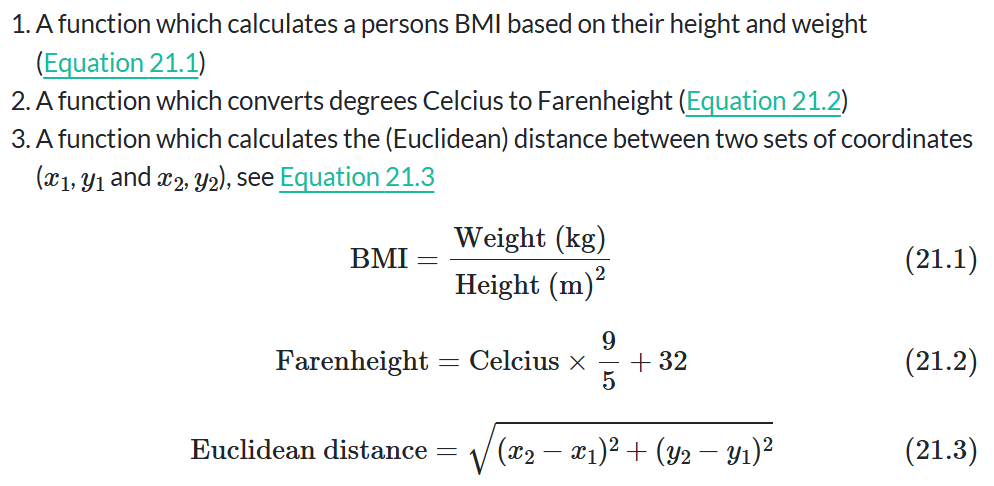

In [22]:
library(IRdisplay)
display_png(file = "Data/formeln.png", width = 600)

In [55]:
bmi <- function(weight, height){
    weight / height^2}

bmi(60, 1.72)

[1] 20.28123

In [28]:
farenheight <- function(celcius){
    (celcius * 9 / 5) + 32}

farenheight(30)

[1] 86

In [35]:
euclidean_distance <- function(x1, x2, y1, y2){
    sqrt((x2-x1)^2 + (y2-y1)^2)
    }

euclidean_distance(12, 15, 23, 20)

[1] 4.242641

## Task 2: Prepare Analysis
In the next tasks we will look for **“meet” patterns** in our wild boar data. To simplify this, we will only use a subset of our wild boar data: The individuals Rosa and Sabi for the timespan 01.04.2015 - 15.04.2015. Use the dataset `wildschwein_BE_2056.csv` (on moodle). Import the csv as a data.frame and filter it with the aforementioned criteria. You do not need to convert the data.frame to an sf object.

In [51]:
library(tidyverse)

In [68]:
data <- read_delim("Data/wildschwein_BE_2056.csv") %>%
    filter(TierName == "Rosa" | TierName == "Sabi", 
    date(DatetimeUTC) >= "2015-04-01" & date(DatetimeUTC) <= "2015-04-15")


head(data)
unique(data$TierName)
min(data$DatetimeUTC)
max(data$DatetimeUTC)

Rows: 51246 Columns: 6
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr  (2): TierID, TierName
dbl  (3): CollarID, E, N
dttm (1): DatetimeUTC

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


TierID,TierName,CollarID,DatetimeUTC,E,N
<chr>,<chr>,<dbl>,<dttm>,<dbl>,<dbl>
002A,Sabi,12275,2015-04-01 00:00:11,2570372,1205313
002A,Sabi,12275,2015-04-01 00:15:22,2570309,1205262
002A,Sabi,12275,2015-04-01 00:30:11,2570326,1205248
002A,Sabi,12275,2015-04-01 00:45:16,2570315,1205242
002A,Sabi,12275,2015-04-01 01:00:44,2570323,1205237
002A,Sabi,12275,2015-04-01 01:15:17,2570320,1205247


[1] "Sabi" "Rosa"

[1] "2015-04-01 00:00:10 UTC"

[1] "2015-04-15 23:47:56 UTC"

## Task 3: Create Join Key
Have a look at your dataset. You will notice that samples are taken at every full hour, quarter past, half past and quarter to. **The sampling time is usually off by a couple of seconds**.

To compare Rosa and Sabi’s locations, we first need to **match the two animals temporally**. For that we can use a `join`, but **need identical time stamps to serve as a join key**. We therefore need to slightly adjust our time stamps to a common, concurrent interval.

The task is therfore to round the minutes of DatetimeUTC to a multiple of 15 (00, 15, 30,45) and store the values in a new `column1`. You can use the lubridate function `round_date()` for this. See the examples [here](https://lubridate.tidyverse.org/reference/round_date.html) to see how this goes.

In [69]:
data$column1 <- round_date(data$DatetimeUTC, "15 mins")

In [70]:
head(data)

TierID,TierName,CollarID,DatetimeUTC,E,N,column1
<chr>,<chr>,<dbl>,<dttm>,<dbl>,<dbl>,<dttm>
002A,Sabi,12275,2015-04-01 00:00:11,2570372,1205313,2015-04-01 00:00:00
002A,Sabi,12275,2015-04-01 00:15:22,2570309,1205262,2015-04-01 00:15:00
002A,Sabi,12275,2015-04-01 00:30:11,2570326,1205248,2015-04-01 00:30:00
002A,Sabi,12275,2015-04-01 00:45:16,2570315,1205242,2015-04-01 00:45:00
002A,Sabi,12275,2015-04-01 01:00:44,2570323,1205237,2015-04-01 01:00:00
002A,Sabi,12275,2015-04-01 01:15:17,2570320,1205247,2015-04-01 01:15:00


## Task 4: Measuring distance at concurrent locations
To measure the distance between concurrent locations, we need to follow the following steps.

1. Split the `wildschwein_filter` object into **one data.frame per animal**
2. **Join these datasets** by the new Datetime column created in the last task. The joined observations are temporally close.
3. In the joined dataset, **calculate Euclidean distances** between concurrent observations and store the values in a new column
4. **Use a reasonable threshold on distance** to determine if the animals are also spatially close enough to constitute a meet (we use 100 meters). Store this Boolean information (TRUE/FALSE) in a new column

### Split Data-Frames

In [71]:
rosa <- data %>% filter(TierName == "Rosa")
sabi <- data %>% filter(TierName == "Sabi")

In [72]:
head(rosa)

TierID,TierName,CollarID,DatetimeUTC,E,N,column1
<chr>,<chr>,<dbl>,<dttm>,<dbl>,<dbl>,<dttm>
016A,Rosa,13972,2015-04-01 00:00:10,2570823,1204800,2015-04-01 00:00:00
016A,Rosa,13972,2015-04-01 00:15:14,2570831,1204794,2015-04-01 00:15:00
016A,Rosa,13972,2015-04-01 00:30:11,2570842,1204796,2015-04-01 00:30:00
016A,Rosa,13972,2015-04-01 00:45:17,2570820,1204803,2015-04-01 00:45:00
016A,Rosa,13972,2015-04-01 01:00:44,2570829,1204787,2015-04-01 01:00:00
016A,Rosa,13972,2015-04-01 01:15:06,2570831,1204767,2015-04-01 01:15:00


### Join Datasets

In [73]:
data_joined <- full_join(rosa, sabi, by = "column1", suffix = c(".rosa", ".sabi"))
head(data_joined)

TierID.rosa,TierName.rosa,CollarID.rosa,DatetimeUTC.rosa,E.rosa,N.rosa,column1,TierID.sabi,TierName.sabi,CollarID.sabi,DatetimeUTC.sabi,E.sabi,N.sabi
<chr>,<chr>,<dbl>,<dttm>,<dbl>,<dbl>,<dttm>,<chr>,<chr>,<dbl>,<dttm>,<dbl>,<dbl>
016A,Rosa,13972,2015-04-01 00:00:10,2570823,1204800,2015-04-01 00:00:00,002A,Sabi,12275,2015-04-01 00:00:11,2570372,1205313
016A,Rosa,13972,2015-04-01 00:15:14,2570831,1204794,2015-04-01 00:15:00,002A,Sabi,12275,2015-04-01 00:15:22,2570309,1205262
016A,Rosa,13972,2015-04-01 00:30:11,2570842,1204796,2015-04-01 00:30:00,002A,Sabi,12275,2015-04-01 00:30:11,2570326,1205248
016A,Rosa,13972,2015-04-01 00:45:17,2570820,1204803,2015-04-01 00:45:00,002A,Sabi,12275,2015-04-01 00:45:16,2570315,1205242
016A,Rosa,13972,2015-04-01 01:00:44,2570829,1204787,2015-04-01 01:00:00,002A,Sabi,12275,2015-04-01 01:00:44,2570323,1205237
016A,Rosa,13972,2015-04-01 01:15:06,2570831,1204767,2015-04-01 01:15:00,002A,Sabi,12275,2015-04-01 01:15:17,2570320,1205247


### Calculate Euclidean distances 
In the joined dataset, calculate Euclidean distances between concurrent observations and store the values in a new column

--> ich habe ja eine Funktion `euclidean_distance` erstellt!!

In [77]:
data_euc_dist <- mutate(data_joined, 
       Euclidean_distance = euclidean_distance(E.rosa, E.sabi, N.rosa, N.sabi))

head(data_euc_dist)

TierID.rosa,TierName.rosa,CollarID.rosa,DatetimeUTC.rosa,E.rosa,N.rosa,column1,TierID.sabi,TierName.sabi,CollarID.sabi,DatetimeUTC.sabi,E.sabi,N.sabi,Euclidean_distance
<chr>,<chr>,<dbl>,<dttm>,<dbl>,<dbl>,<dttm>,<chr>,<chr>,<dbl>,<dttm>,<dbl>,<dbl>,<dbl>
016A,Rosa,13972,2015-04-01 00:00:10,2570823,1204800,2015-04-01 00:00:00,002A,Sabi,12275,2015-04-01 00:00:11,2570372,1205313,682.8943
016A,Rosa,13972,2015-04-01 00:15:14,2570831,1204794,2015-04-01 00:15:00,002A,Sabi,12275,2015-04-01 00:15:22,2570309,1205262,700.9568
016A,Rosa,13972,2015-04-01 00:30:11,2570842,1204796,2015-04-01 00:30:00,002A,Sabi,12275,2015-04-01 00:30:11,2570326,1205248,685.8371
016A,Rosa,13972,2015-04-01 00:45:17,2570820,1204803,2015-04-01 00:45:00,002A,Sabi,12275,2015-04-01 00:45:16,2570315,1205242,669.1526
016A,Rosa,13972,2015-04-01 01:00:44,2570829,1204787,2015-04-01 01:00:00,002A,Sabi,12275,2015-04-01 01:00:44,2570323,1205237,676.5464
016A,Rosa,13972,2015-04-01 01:15:06,2570831,1204767,2015-04-01 01:15:00,002A,Sabi,12275,2015-04-01 01:15:17,2570320,1205247,701.6919


### Determine *meet*
Use a reasonable threshold on distance to determine if the animals are also spatially close enough to constitute a meet (we use **100 meters**). Store this Boolean information (`TRUE/FALSE`) in a new column

In [78]:
data_euc_dist <- data_euc_dist %>% mutate(
    meet = Euclidean_distance <= 100)

In [79]:
head(data_euc_dist)

TierID.rosa,TierName.rosa,CollarID.rosa,DatetimeUTC.rosa,E.rosa,N.rosa,column1,TierID.sabi,TierName.sabi,CollarID.sabi,DatetimeUTC.sabi,E.sabi,N.sabi,Euclidean_distance,meet
<chr>,<chr>,<dbl>,<dttm>,<dbl>,<dbl>,<dttm>,<chr>,<chr>,<dbl>,<dttm>,<dbl>,<dbl>,<dbl>,<lgl>
016A,Rosa,13972,2015-04-01 00:00:10,2570823,1204800,2015-04-01 00:00:00,002A,Sabi,12275,2015-04-01 00:00:11,2570372,1205313,682.8943,FALSE
016A,Rosa,13972,2015-04-01 00:15:14,2570831,1204794,2015-04-01 00:15:00,002A,Sabi,12275,2015-04-01 00:15:22,2570309,1205262,700.9568,FALSE
016A,Rosa,13972,2015-04-01 00:30:11,2570842,1204796,2015-04-01 00:30:00,002A,Sabi,12275,2015-04-01 00:30:11,2570326,1205248,685.8371,FALSE
016A,Rosa,13972,2015-04-01 00:45:17,2570820,1204803,2015-04-01 00:45:00,002A,Sabi,12275,2015-04-01 00:45:16,2570315,1205242,669.1526,FALSE
016A,Rosa,13972,2015-04-01 01:00:44,2570829,1204787,2015-04-01 01:00:00,002A,Sabi,12275,2015-04-01 01:00:44,2570323,1205237,676.5464,FALSE
016A,Rosa,13972,2015-04-01 01:15:06,2570831,1204767,2015-04-01 01:15:00,002A,Sabi,12275,2015-04-01 01:15:17,2570320,1205247,701.6919,FALSE


In [112]:
data_meets <- data_euc_dist %>%
    filter(meet == TRUE)

In [113]:
head(data_meets)

TierID.rosa,TierName.rosa,CollarID.rosa,DatetimeUTC.rosa,E.rosa,N.rosa,column1,TierID.sabi,TierName.sabi,CollarID.sabi,DatetimeUTC.sabi,E.sabi,N.sabi,Euclidean_distance,meet
<chr>,<chr>,<dbl>,<dttm>,<dbl>,<dbl>,<dttm>,<chr>,<chr>,<dbl>,<dttm>,<dbl>,<dbl>,<dbl>,<lgl>
016A,Rosa,13972,2015-04-02 04:45:15,2570399,1205393,2015-04-02 04:45:00,002A,Sabi,12275,2015-04-02 04:45:16,2570422,1205393,23.56397,TRUE
016A,Rosa,13972,2015-04-02 05:00:12,2570395,1205393,2015-04-02 05:00:00,002A,Sabi,12275,2015-04-02 05:00:11,2570387,1205381,14.16954,TRUE
016A,Rosa,13972,2015-04-02 18:00:17,2570396,1205388,2015-04-02 18:00:00,002A,Sabi,12275,2015-04-02 18:00:15,2570368,1205370,33.20166,TRUE
016A,Rosa,13972,2015-04-02 18:30:13,2570350,1205396,2015-04-02 18:30:00,002A,Sabi,12275,2015-04-02 18:30:23,2570409,1205318,97.62235,TRUE
016A,Rosa,13972,2015-04-03 04:00:15,2570394,1205391,2015-04-03 04:00:00,002A,Sabi,12275,2015-04-03 04:00:13,2570298,1205391,95.87161,TRUE
016A,Rosa,13972,2015-04-03 04:15:10,2570395,1205397,2015-04-03 04:15:00,002A,Sabi,12275,2015-04-03 04:15:09,2570302,1205386,93.38390,TRUE


## Task 5: Visualize data
Now, visualize the meets spatially in a way that you think reasonable. For example in the plot as shows below. To produce this plot we:

- Used the individual dataframes from rosa and sabi (from the previous task)
- Used the joined dataset (also from the previous task), filtered to only the meets
- Manually changed the x and y axis limits

Warning message:
"Removed 20 rows containing missing values or values outside the scale range (`geom_point()`)."


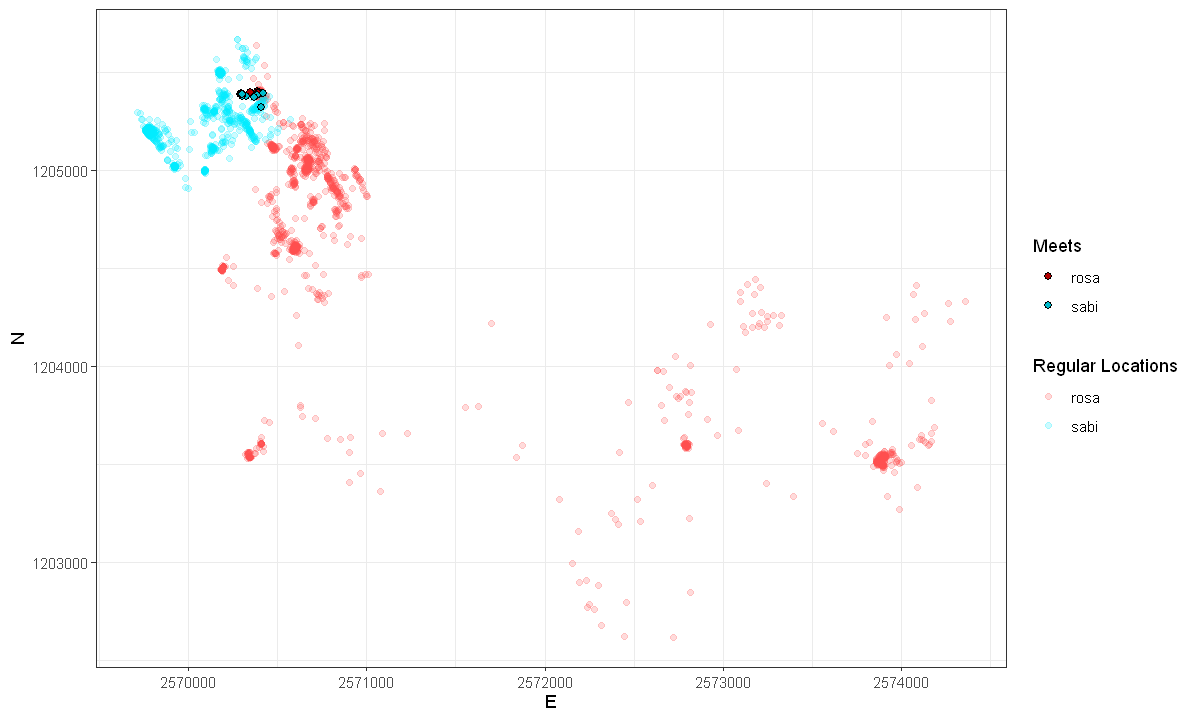

In [137]:
# Plotgrösse festlegen
options(repr.plot.width = 10, repr.plot.height = 6)

ggplot() +
    # Regular locations
    geom_point(data = data_euc_dist, aes(x = E.rosa, y = N.rosa, color = "rosa"), alpha = 0.2) +
    geom_point(data = data_euc_dist, aes(x = E.sabi, y = N.sabi, color = "sabi"), alpha = 0.2) +

    # Meets
    geom_point(data = data_meets, aes(x = E.rosa, y = N.rosa, fill = "rosa"),
             shape = 21, color = "black", size = 2) +
    geom_point(data = data_meets, aes(x = E.sabi, y = N.sabi, fill = "sabi"),
             shape = 21, color = "black", size = 2) +

    # Farben definieren
    scale_color_manual(
        name = "Regular Locations",
        values = c("rosa" = "#ff4d4d", "sabi" = "#00eaff")) +
    scale_fill_manual(
        name = "Meets",
        values = c("rosa" = "#b30000", "sabi" = "#00bbcc")) +
  
    # Achsenbeschriftung
    labs(
        x = "E",
        y = "N") +
  
    theme_bw() +
    theme(legend.position = "right")